In [1]:
import cv2
import time
import numpy as np
from clipLine import *
import matplotlib.pyplot as plt
import matplotlib.patches as patches

%matplotlib notebook

In [2]:
img = cv2.imread('vp.jpg')
lines_near_vps = np.load('lines_near_vps.npy')

<IPython.core.display.Javascript object>


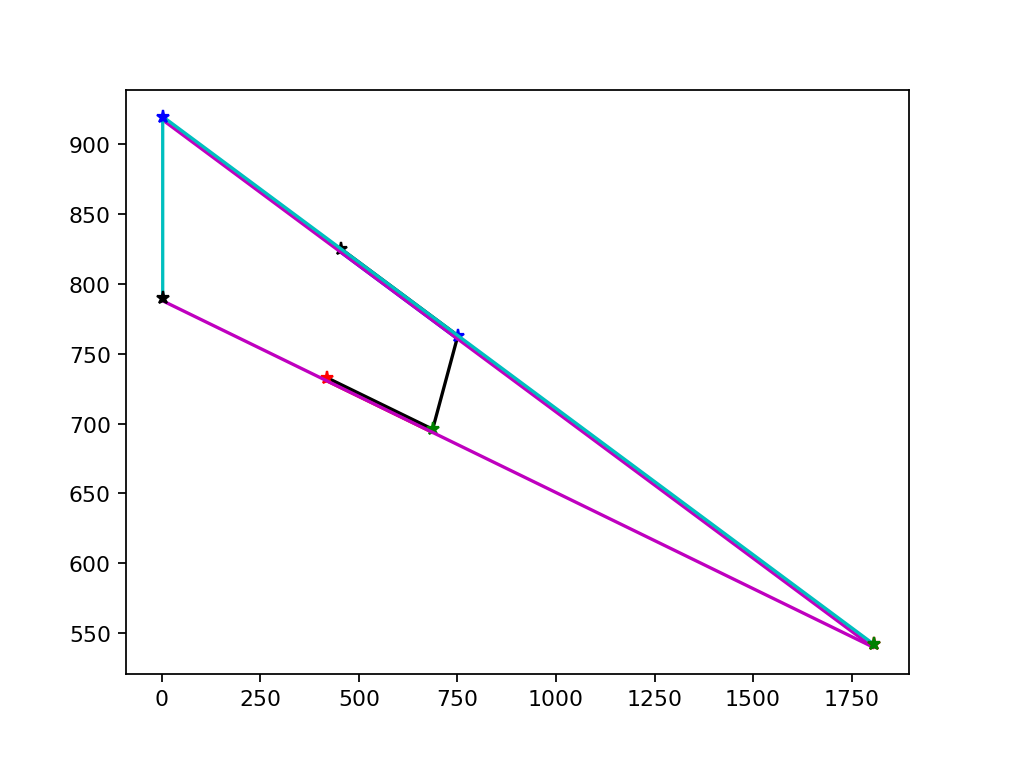

sP1= [[ 1.80409677e+03  1.80462162e+03 -0.00000000e+00 -0.00000000e+00]
 [ 5.40000000e+02  5.40000000e+02  9.17885135e+02  7.88219331e+02]
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00]]


In [44]:
def sortPts(P):
    theta = np.zeros(4)
    mX = np.mean(P[0,: ])
    mY = np.mean(P[1, :])
    for k in range(4):
        Dx = P[0, k] - mX
        Dy = P[1, k] - mY
        theta[k] = np.arctan2(Dy, Dx)
    
    indices = sorted(range(len(theta)), key = lambda index: theta[index])
    sP = P[:, indices]
    return sP, indices

def sortPtsIdx(p,i,j):
    P = np.array([[p[i, 0, 0],p[i, 0, 2],p[j, 0, 0],p[j, 0, 2]],
                  [p[i, 0, 1],p[i, 0, 3],p[j, 0, 1],p[j, 0, 3]],
                  [  1,                1,         1,        1]]).astype('float64')
    return sortPts(P)

i=0
j=1
sP, idx = sortPtsIdx(lines_near_vps, i, j)
\

figQ, axQ = plt.subplots()
R=['r','g','b','k']
axQ.plot(lines_near_vps[i,0,0::2], lines_near_vps[i,0,1::2],'r')
axQ.plot(lines_near_vps[j,0,0::2], lines_near_vps[j,0,1::2],'b')
axQ.plot(sP[0,:]+2,sP[1,:]+2, 'k')

for k in range(4):
    axQ.plot(sP[0,k]+2,sP[1,k]+2, '*'+R[k])
    
p = lines_near_vps  

line_a = np.cross(np.array([p[i,0,0],p[i,0,1],1.]),np.array([p[i,0,2],p[i,0,3],1.])) 
line_b = np.cross(np.array([p[j,0,0],p[j,0,1],1.]),np.array([p[j,0,2],p[j,0,3],1.]))
line_a /= line_a[2]
line_b /= line_b[2]

pl1, pl2, success = clipLine(line_a, (0,1080//2), (1920,1080//2))
pl3, pl4, success = clipLine(line_b, (0,1080//2), (1920,1080//2))
axQ.plot([pl1[0],pl2[0]],[pl1[1],pl2[1]],'m')
axQ.plot([pl3[0],pl4[0]],[pl3[1],pl4[1]],'m')
P1=np.array([[pl1[0],pl2[0],pl3[0],pl4[0]],[pl1[1],pl2[1],pl3[1],pl4[1]],[1.,1.,1.,1]])
sP1, idx1 = sortPts(P1)
print("sP1=",sP1)
axQ.plot(sP1[0,:]+2,sP1[1,:]+2, 'c')
for k in range(4):
    axQ.plot(sP1[0,k]+2,sP1[1,k]+2, '*'+R[k])

In [42]:
lines_near_vps

array([[[ 416,  731,  685,  694]],

       [[ 453,  823,  749,  761]],

       [[ 416,  731,  685,  694]],

       ...,

       [[1610,  604, 1850,  613]],

       [[1610,  604, 1850,  613]],

       [[ 939,  713, 1078,  736]]], dtype=int32)

<IPython.core.display.Javascript object>


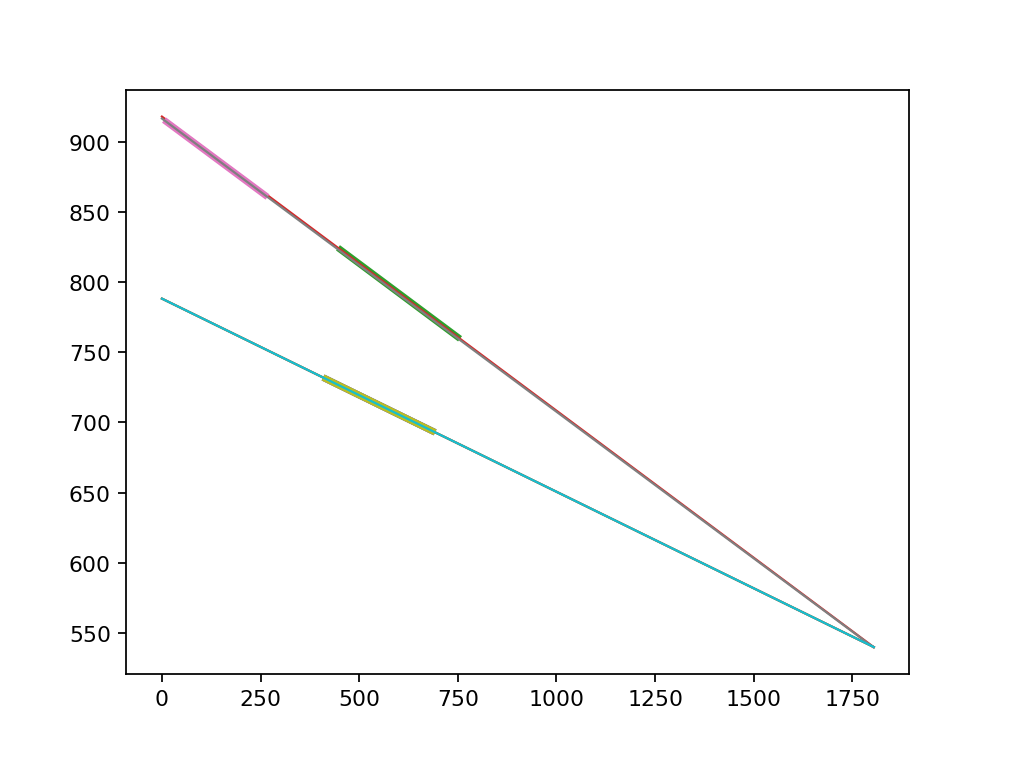

n= 5


<IPython.core.display.Javascript object>


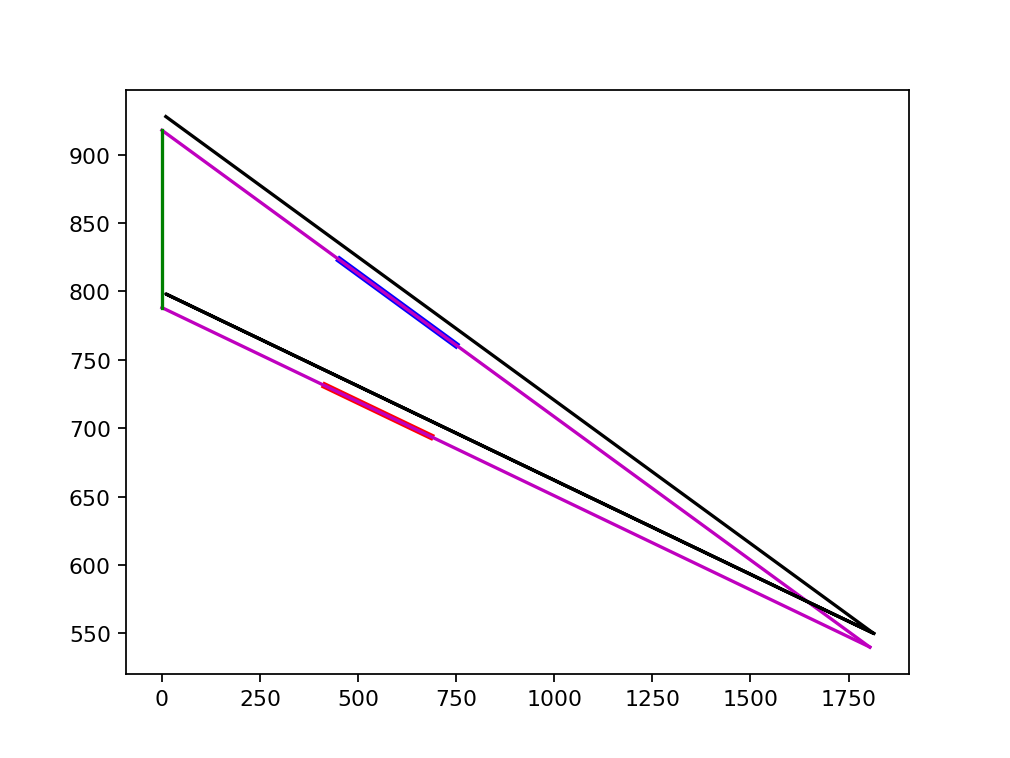

D(0,1) =129.665804


<IPython.core.display.Javascript object>


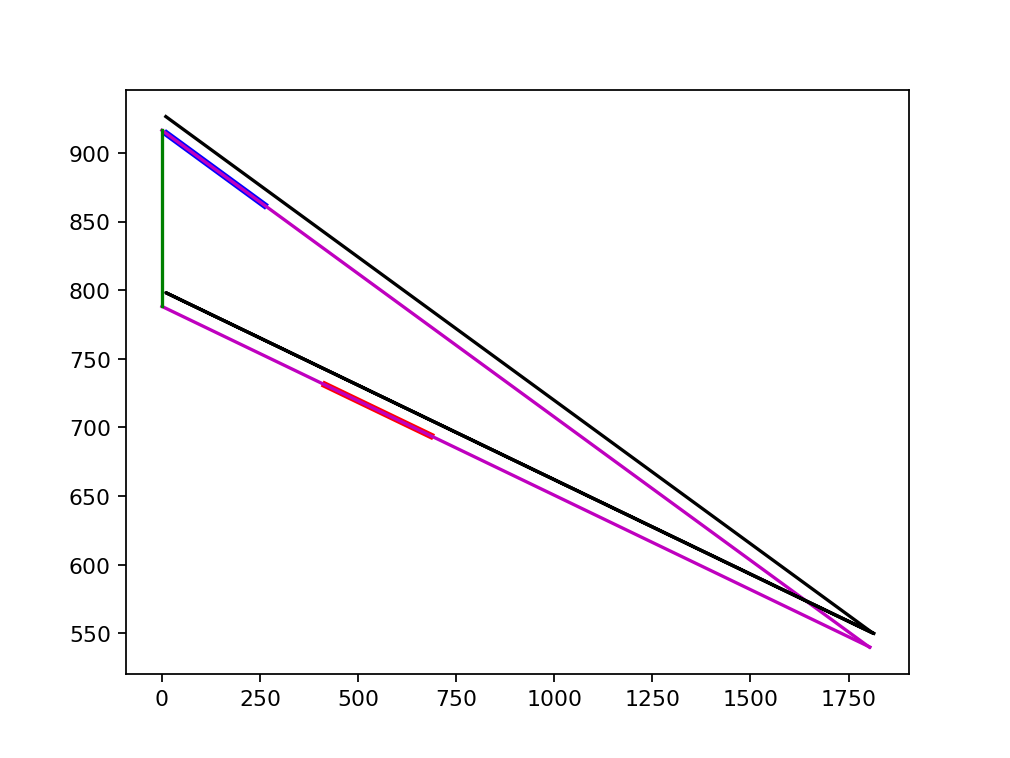

D(0,3) =128.286693


<IPython.core.display.Javascript object>


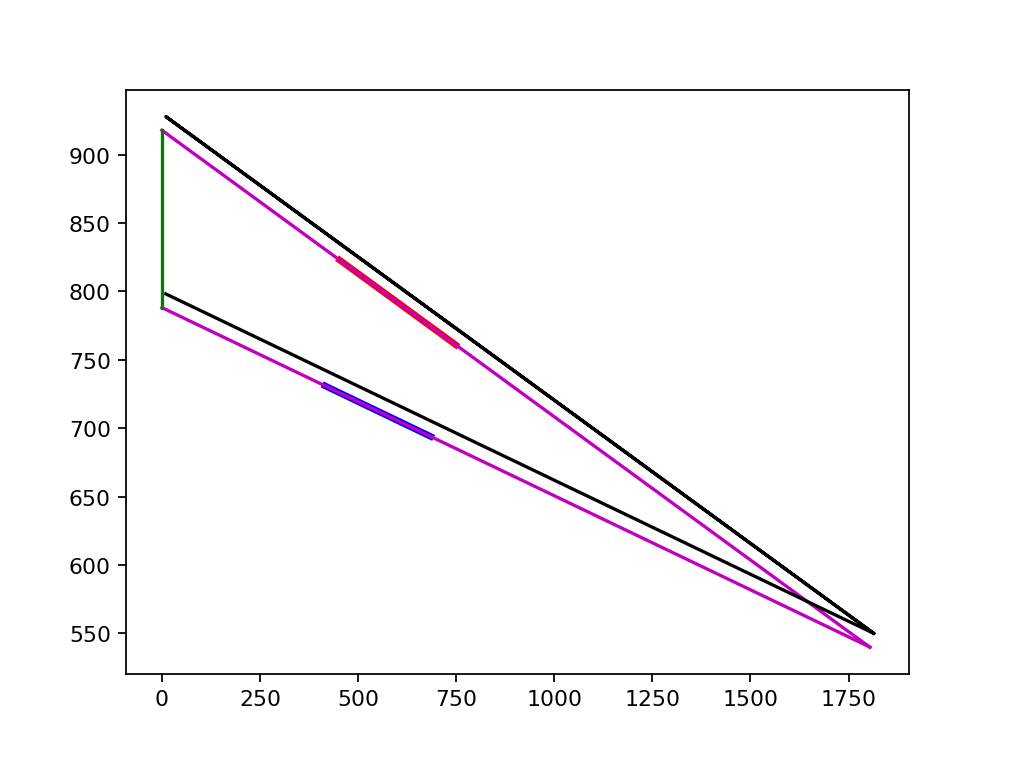

D(1,2) =129.665804


<IPython.core.display.Javascript object>


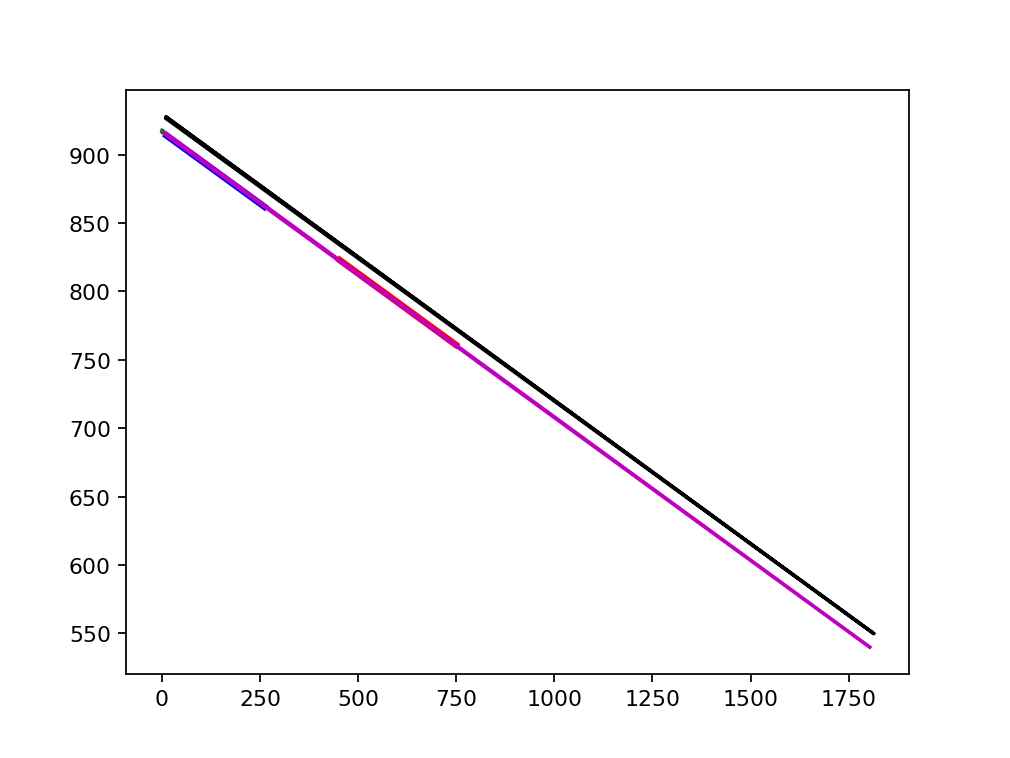

D(1,3) =1.379111


<IPython.core.display.Javascript object>


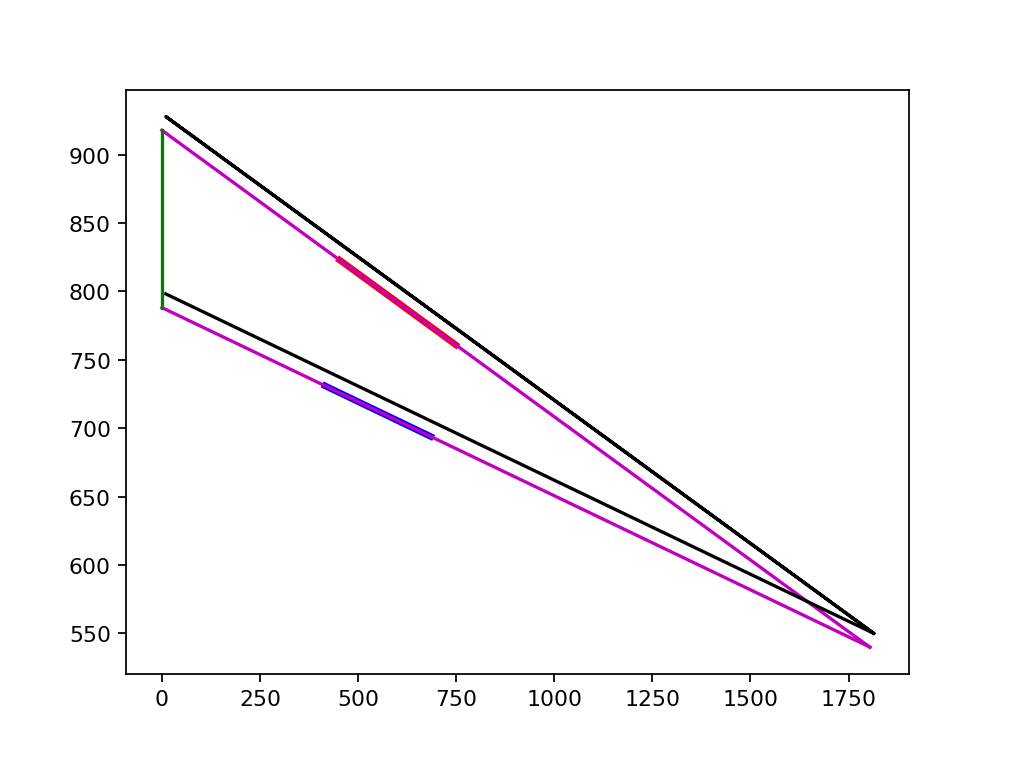

D(1,4) =129.665804


<IPython.core.display.Javascript object>


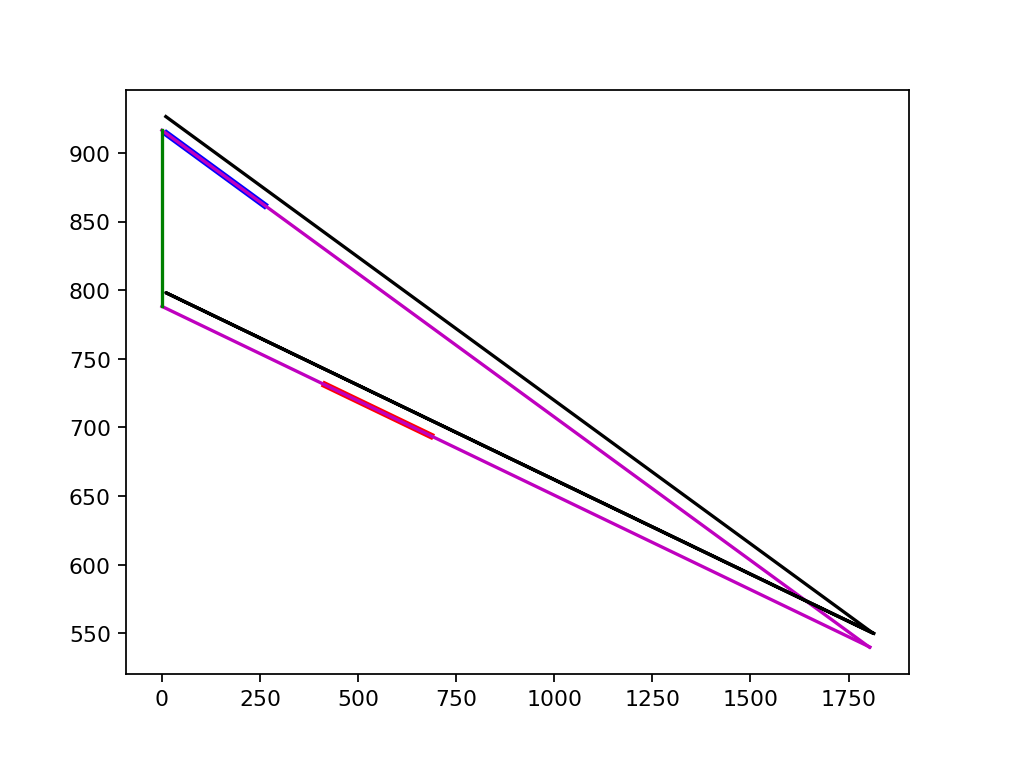

D(2,3) =128.286693


<IPython.core.display.Javascript object>


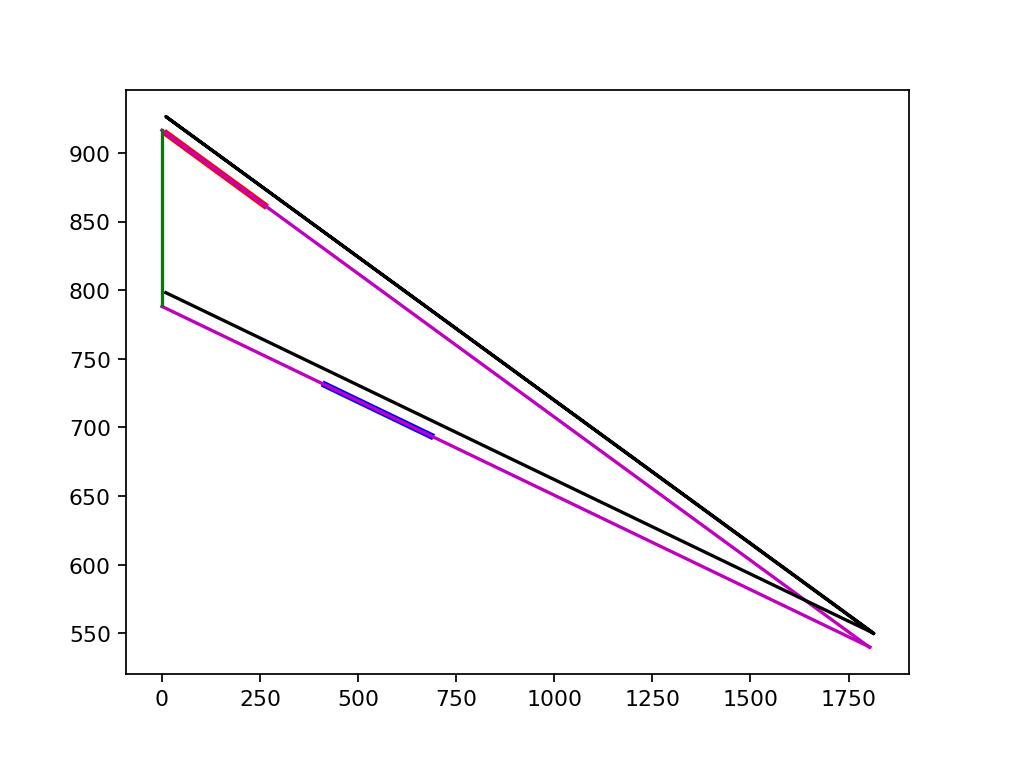

D(3,4) =128.286693
Iguales =  3
sqrt(D)= [129.66580428 128.28669324 129.66580428   1.37911104 129.66580428
 128.28669324 128.28669324]


In [45]:
def line_similarity(line_a, line_b, threshold=1, normType = 0, region=[1920, 1080]):
    distance = np.inf
    if normType == 1:
        # Normalize the lines as homogeneous variable
        linea_n = line_a / line_a[2]
        lineb_n = line_b / line_b[2]
        tmp = linea_n[:2] - lineb_n[:2]
        distance = np.dot(tmp, tmp)
    elif normType == 2:
        # Normalize the lines according to their size
        linea_n = line_b / np.linalg.norm(line_b)
        linea_n = line_a / np.linalg.norm(line_a)
        tmp = lineb_n - linea_n
        distance = np.dot(tmp, tmp)
    else:
        
        pl1, pl2, success = clipLine(line_a, (0,region[1]//2), (region[0],region[1]//2))
        
        if success == True:
            pl3, pl4, success = clipLine(line_b, (0,region[1]//2), (region[0],region[1]//2))
            
            if success == True:
                
                P = np.hstack([pl1,pl2,pl3,pl4]).reshape(4,3).transpose()
                
                sP, idx = sortPts(P)
                
                d=[]
                tmp = sP[:2,0]-sP[:2,1]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                tmp = sP[:2,2]-sP[:2,3]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                pts = P.copy()
                if d[0] > d[1]:
                    distance = d[0]
                    pts = np.hstack([pts, np.array(sP[:,0],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,1],ndmin=2).transpose()])
                else:
                    distance = d[1]
                    pts = np.hstack([pts, np.array(sP[:,2],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,3],ndmin=2).transpose()])

    # Compute similarity
    return distance <= (threshold * threshold), distance, pts


l = lines_near_vps.copy().astype('float64')
n,_,_ = l.shape

figA, axA = plt.subplots()

n = 5
print("n=",n)

lh = np.zeros((3,n))
for i in range(n): 
    axA.plot([l[i,0,0], l[i,0,2]],[l[i,0,1], l[i,0,3]],linewidth=3)
    lhm = np.cross(np.array([l[i,0,0],l[i,0,1],1]),np.array([l[i,0,2],l[i,0,3],1]))
    lhm = lhm.astype('float64')
    lhm /= lhm[2]
    lh[:,i] = lhm.copy()
    L1A, L1B, Success = clipLine(lhm, (0,540),(1920,540))
    axA.plot([L1A[0],L1B[0]],[L1A[1],L1B[1]], linewidth=1)
 
N=n*(n+1)//2

FigB = []
AxB = []


D=[]
cont=0
iguales = 0
for i in range(n-1):
    
    Q=np.array(l[i,0,:]).reshape(2,2).transpose()
    for j in range(i+1, n):
        W=np.array(l[j,0,:]).reshape(2,2).transpose()
        if np.max(np.abs(Q-W)) != 0:
            fg, ax= plt.subplots()
            FigB.append(fg)
            AxB.append(ax)
            ax.plot([l[i,0,0], l[i,0,2]],[l[i,0,1], l[i,0,3]],'r',linewidth=3)
            ax.plot([l[j,0,0], l[j,0,2]],[l[j,0,1], l[j,0,3]],'b',linewidth=3)
            similar, d, pts = line_similarity(lh[:,i], lh[:,j])
            
            ax.plot([pts[0,0],pts[0,1]],[pts[1,0],pts[1,1]],'m')
            ax.plot([pts[0,2],pts[0,3]],[pts[1,2],pts[1,3]],'m')
            ax.plot([pts[0,4],pts[0,5]],[pts[1,4],pts[1,5]],'g')
            ax.plot(pts[0,:4]+10,pts[1,:4]+10, 'k')
            print ("D(%d,%d) =%f" % (i,j, np.sqrt(d)))
            D.append(d)
            cont+=1
        else:
            iguales +=1
        
        
print("Iguales = ", iguales)
print("sqrt(D)=",np.sqrt(D))

In [ ]:
help (np.array)